<a href="https://colab.research.google.com/github/Ab-126/Machine_Learning/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample, columns=["feature1", "feature2", "feature3"])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

In [ ]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [ ]:
import plotly.express as px

fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'], color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12, line=dict(width=2, color='DarkSlateGrey')), selector=dict(mode='markers'))

fig.show()

In [ ]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [ ]:
# Step 1 - Apply Standard Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:, 0:3] = scaler.fit_transform(df.iloc[:, 0:3])

In [ ]:
# Step 2 - Find convariance matrix
covariance_matrix = np.cov([df.iloc[:, 0], df.iloc[:, 1], df.iloc[:, 2]])
print("Covariance matrix: \n", covariance_matrix)

Covariance matrix: 
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [ ]:
# Step 3 - Find EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [ ]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [ ]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

In [ ]:
df.head()

,feature1,feature2,feature3,target
2,-0.700809,-1.525586,-1.749156,1
34,-0.224481,-1.010757,0.491251,0
14,-0.011456,-0.046935,-0.649616,1
11,1.342296,-0.962723,-1.184163,1
12,-2.571350,-0.299561,-0.054040,1


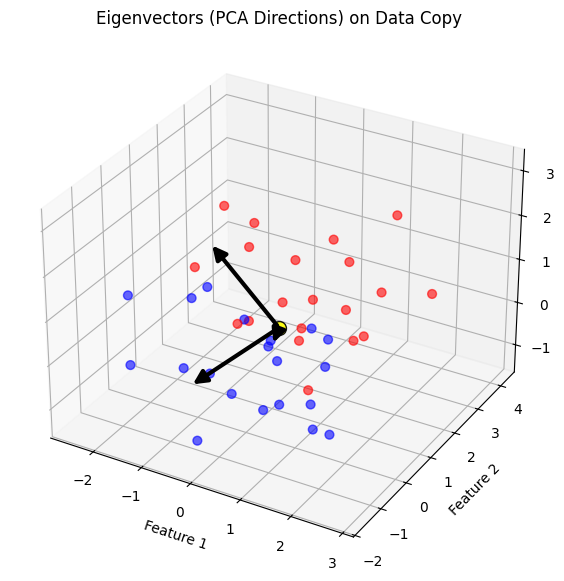

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

# --- 1. MODERN COMPATIBLE 3D ARROW CLASS ---
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

# --- 2. GENERATE DATA ---
np.random.seed(23)
class1_sample = np.random.multivariate_normal([0, 0, 0], np.eye(3), 20)
class2_sample = np.random.multivariate_normal([1, 1, 1], np.eye(3), 20)

# Create the original df with a 'target' column intact
df = pd.concat([pd.DataFrame(class1_sample), pd.DataFrame(class2_sample)], ignore_index=True)
df['target'] = [0]*20 + [1]*20

# --- SAFE BLOCK: Create an isolated copy for plotting ---
plot_df = df.copy()
# Drop target column so it doesn't interfere with covariance calculations
features_only = plot_df.drop(columns=['target'])

# Calculate Covariance and Eigenvectors safely using features only
cov_matrix = np.cov(features_only, rowvar=False)
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# Mean coordinates (Center point) using numeric column index positioning
mean_x = features_only.iloc[:, 0].mean()
mean_y = features_only.iloc[:, 1].mean()
mean_z = features_only.iloc[:, 2].mean()

# --- 3. PLOT MATRIX WITH 3D AXES ---
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using index coordinates, colored by target
ax.scatter(features_only.iloc[:, 0],
           features_only.iloc[:, 1],
           features_only.iloc[:, 2],
           c=plot_df['target'], cmap='bwr', s=40, alpha=0.6)

# Central yellow mean point
ax.plot([mean_x], [mean_y], [mean_z], 'o', markersize=10, color='yellow', markeredgecolor='black', alpha=0.9)

# Render the corrected 3D arrows using the updated draw method
for v in eigen_vectors.T:
    a = Arrow3D([mean_x, mean_x + v[0]*2],
                [mean_y, mean_y + v[1]*2],
                [mean_z, mean_z + v[2]*2],
                mutation_scale=20, lw=3, arrowstyle="-|>", color="black")
    ax.add_artist(a)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
plt.title('Eigenvectors (PCA Directions) on Data Copy')

plt.show()


In [ ]:
pc = eigen_vectors[0:2]
pc

array([[-0.61002583, -0.69239396,  0.3853039 ],
       [-0.53982115,  0.00718615, -0.84174906]])

In [ ]:
df.head()

,0,1,2,target
0,0.666988,0.025813,-0.777619,0
1,0.948634,0.701672,-1.051082,0
2,-0.367548,-1.137460,-1.322148,0
3,1.772258,-0.347459,0.670140,0
4,0.322272,0.060343,-1.043450,0


In [ ]:
transformed_df = np.dot(df.iloc[:, 0:3], pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df, columns=['PC1', 'PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,-0.724373,0.294692,0
1,-1.469510,0.377697,0
2,0.502355,1.303153,0
3,-0.582337,-1.523289,0
4,-0.640420,0.704788,0
